In [1]:
from pathlib import Path

FIGS_ROOT = Path("figs")
PLOT_OUTPUT_DIR = FIGS_ROOT / "dimensionality_analysis"
CONFIG_IDS = ["config_018", "config_013", "config_012", "config_014", "config_015", "config_017"]
PRIORS = ["uniform", "normal", "exponential", "grid"]
LOAD_RAW = True
RAW_CONFIG_IDS = ["config_018", "config_013", "config_012", "config_014", "config_015", "config_017"]


# Dimensionality Analysis

This notebook compares the clean 1D-6D `toy_example_nD_tidy.py` sweep using the summary artifacts already written to `figs/`.

It is organized in two layers:
- A fast summary layer driven by `config.json`, `posterior_errors/analysis_bundle.json`, `verifications/model_quality_summary.json`, and `verifications/reweighting_quality_summary.json`.
- An optional compact-store deep dive driven by `ratio_map.npy` and the ratio HLD interval arrays referenced by each `analysis_bundle.json`.

Notes:
- The default sweep is `config_018, 013, 012, 014, 015, 017`, which resolve to dimensions `1, 2, 3, 4, 5, 6`.
- The raw deep-dive loader automatically samples very large compact-store arrays so higher-dimensional examples remain usable.

In [2]:
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

from src.dimensionality_analysis import (
    RAW_MAX_POINTS_PER_CONFIG,
    load_dimensionality_summary,
    load_raw_compact_store,
)

warnings.simplefilter("default")
pd.options.display.max_columns = 50
pd.options.display.float_format = "{:.3f}".format

PRIOR_COLORS = {
    "uniform": "#1f77b4",
    "normal": "#d17a22",
    "exponential": "#2a9d4b",
    "grid": "#7b61ff",
}
PRIOR_MARKERS = {
    "uniform": "o",
    "normal": "s",
    "exponential": "^",
    "grid": "D",
}
PRIOR_LABELS = {prior: prior.title() for prior in PRIOR_COLORS}


def active_priors(dataframe):
    if dataframe is None or getattr(dataframe, "empty", True) or "prior" not in dataframe.columns:
        return list(PRIORS)
    present_priors = set(dataframe["prior"].dropna().astype(str))
    return [prior for prior in PRIORS if prior in present_priors]


def build_prior_legend_handles(priors):
    return [
        Line2D(
            [0],
            [0],
            marker=PRIOR_MARKERS.get(prior, "o"),
            color="white",
            label=PRIOR_LABELS.get(prior, prior),
            markerfacecolor="gray",
            markeredgecolor="black",
            markersize=9,
        )
        for prior in priors
    ]


def normalized_config_ids(config_ids):
    return [config_id if str(config_id).startswith("config_") else f"config_{config_id}" for config_id in config_ids]


def build_compact_metric_table(runs_df):
    columns = [
        "config_id",
        "dimension",
        "prior",
        "pooled_rmse_log_r10",
        "median_rmse_log_r10",
        "worst_rmse_log_r10",
        "median_ess_fraction",
        "median_swd",
        "coverage_68",
        "coverage_95",
        "mean_interval_width_68",
        "mean_interval_width_95",
    ]
    return runs_df[columns].sort_values(["dimension", "prior"]).reset_index(drop=True)


def plot_prior_lines(ax, data, metric, title, ylabel, *, logy=False):
    dimensions = sorted(data["dimension"].unique()) if not data.empty else []
    for prior in active_priors(data):
        subset = data.loc[data["prior"] == prior].sort_values("dimension")
        if subset.empty:
            continue
        ax.plot(
            subset["dimension"],
            subset[metric],
            marker=PRIOR_MARKERS.get(prior, "o"),
            linewidth=2,
            color=PRIOR_COLORS.get(prior),
            label=PRIOR_LABELS.get(prior, prior),
        )
    ax.set_title(title)
    ax.set_xlabel("Dimension")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    if dimensions:
        ax.set_xticks(dimensions)
    if logy:
        ax.set_yscale("log")


def add_shared_colorbar(fig, axes, mappable, label, *, right=0.88, pad=0.02, top=0.9, bottom=0.14, left=0.08, wspace=0.28):
    axes_list = np.atleast_1d(axes).tolist()
    fig.subplots_adjust(left=left, right=right, bottom=bottom, top=top, wspace=wspace)
    colorbar = fig.colorbar(mappable, ax=axes_list, fraction=0.035, pad=pad)
    colorbar.set_label(label)
    return colorbar


def save_figure(fig, filename, *, dpi=200):
    PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = PLOT_OUTPUT_DIR / f"{filename}.pdf"
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    return output_path


def build_correlation_summary(runs_df, pairs_df):
    rows = []
    if pairs_df.empty:
        return pd.DataFrame()

    for (config_id, dimension, prior), subset in pairs_df.groupby(["config_id", "dimension", "prior"]):
        run_row = runs_df.loc[
            (runs_df["config_id"] == config_id)
            & (runs_df["dimension"] == dimension)
            & (runs_df["prior"] == prior)
        ].iloc[0]
        rows.append(
            {
                "config_id": config_id,
                "dimension": dimension,
                "prior": prior,
                "stored_spearman_rmse_vs_distance": run_row["spearman_rmse_vs_distance"],
                "empirical_spearman_rmse_vs_distance": subset["distance"].corr(
                    subset["rmse_log_r10"], method="spearman"
                ),
                "empirical_pearson_rmse_vs_distance": subset["distance"].corr(
                    subset["rmse_log_r10"], method="pearson"
                ),
                "stored_spearman_swd_vs_distance": run_row["spearman_swd_vs_distance"],
                "empirical_spearman_swd_vs_distance": subset["distance"].corr(
                    subset["swd"], method="spearman"
                ),
                "empirical_pearson_swd_vs_distance": subset["distance"].corr(
                    subset["swd"], method="pearson"
                ),
                "empirical_spearman_ess_fraction_vs_distance": subset["distance"].corr(
                    subset["ess_fraction"], method="spearman"
                ),
            }
        )
    return pd.DataFrame(rows).sort_values(["dimension", "prior"]).reset_index(drop=True)


def build_scaling_observation_markdown(runs_df):
    if runs_df.empty:
        return Markdown("No runs were loaded.")

    mean_by_dim = runs_df.groupby("dimension").agg(
        mean_pooled_rmse=("pooled_rmse_log_r10", "mean"),
        mean_coverage_68=("coverage_68", "mean"),
        mean_coverage_95=("coverage_95", "mean"),
        mean_ess_fraction=("median_ess_fraction", "mean"),
        mean_swd=("median_swd", "mean"),
    ).sort_index()
    growth = mean_by_dim["mean_pooled_rmse"].pct_change()

    lines = ["### Scaling interpretation"]
    if growth.notna().any():
        sharpest_dim = int(growth.fillna(-np.inf).idxmax())
        sharpest_position = list(mean_by_dim.index).index(sharpest_dim)
        previous_dim = int(mean_by_dim.index[sharpest_position - 1])
        lines.append(
            f"- The sharpest average pooled-RMSE jump occurs between **{previous_dim}D** and **{sharpest_dim}D**, "
            f"where the mean pooled RMSE rises from **{mean_by_dim.loc[previous_dim, 'mean_pooled_rmse']:.2f}** "
            f"to **{mean_by_dim.loc[sharpest_dim, 'mean_pooled_rmse']:.2f}**."
        )

    coverage_collapse = mean_by_dim.loc[mean_by_dim["mean_coverage_68"] < 0.50]
    if not coverage_collapse.empty:
        collapse_dim = int(coverage_collapse.index[0])
        lines.append(
            f"- Mean 68% HLD coverage drops below **0.50** at **{collapse_dim}D**, "
            f"which is a strong sign that uncertainty is becoming under-dispersed in the higher-dimensional runs."
        )

    ess_collapse = mean_by_dim.loc[mean_by_dim["mean_ess_fraction"] < 0.01]
    if not ess_collapse.empty:
        ess_dim = int(ess_collapse.index[0])
        lines.append(
            f"- Median effective-sample-size fraction falls below **1%** by **{ess_dim}D**, "
            f"which matches the worsening reweighting difficulty seen in the SWD plots."
        )

    final_dim = int(mean_by_dim.index.max())
    lines.append(
        f"- By **{final_dim}D**, the sweep combines larger ratio error, lower ESS, and much weaker empirical coverage, "
        "so the failure mode is not just a single metric moving in isolation."
    )
    return Markdown("\n".join(lines))


def plot_curve_family(curves_df, metric, ylabel, title_prefix, *, figsize=None):
    priors = active_priors(curves_df)
    dimensions = sorted(curves_df["dimension"].unique()) if not curves_df.empty else []
    dimension_colors = {
        dim: plt.cm.viridis(index)
        for dim, index in zip(
            dimensions,
            np.linspace(0.1, 0.9, num=max(len(dimensions), 1)),
        )
    }
    if not priors:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.set_axis_off()
        return fig
    if figsize is None:
        figsize = (4.2 * len(priors), 4)
    fig, axes = plt.subplots(1, len(priors), figsize=figsize, sharex=True, sharey=True, squeeze=False)
    axes = axes.ravel()
    for ax, prior in zip(axes, priors):
        subset = curves_df.loc[curves_df["prior"] == prior]
        if subset.empty:
            ax.set_axis_off()
            continue
        for dimension in dimensions:
            dimension_slice = subset.loc[subset["dimension"] == dimension].sort_values("x_value")
            if dimension_slice.empty:
                continue
            ax.plot(
                dimension_slice["x_value"],
                dimension_slice[metric],
                linewidth=2,
                color=dimension_colors[dimension],
                label=f"{dimension}D",
            )
        ax.set_title(f"{PRIOR_LABELS.get(prior, prior)}")
        ax.set_xlabel("True value")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
    handles = [
        Line2D([0], [0], color=dimension_colors[dimension], linewidth=2, label=f"{dimension}D")
        for dimension in dimensions
    ]
    if handles:
        fig.legend(handles=handles, loc="upper center", ncol=min(len(handles), 6), frameon=False)
    fig.suptitle(title_prefix, y=1.03)
    fig.tight_layout()
    return fig


def plot_curve_heatmaps(curves_df, metric, colorbar_label, cmap):
    priors = active_priors(curves_df)
    if not priors:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.set_axis_off()
        return fig
    fig, axes = plt.subplots(1, len(priors), figsize=(4.2 * len(priors), 4.5), squeeze=False)
    axes = axes.ravel()
    metric_values = curves_df[metric].to_numpy(dtype=float) if metric in curves_df else np.asarray([], dtype=float)
    finite_values = metric_values[np.isfinite(metric_values)]
    vmin = float(finite_values.min()) if finite_values.size else None
    vmax = float(finite_values.max()) if finite_values.size else None
    images = []
    for ax, prior in zip(axes, priors):
        subset = curves_df.loc[curves_df["prior"] == prior]
        if subset.empty:
            ax.set_axis_off()
            continue
        heatmap = subset.pivot_table(
            index="dimension",
            columns="x_value",
            values=metric,
            aggfunc="mean",
        ).sort_index()
        masked_values = np.ma.masked_invalid(heatmap.to_numpy(dtype=float))
        image = ax.imshow(masked_values, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        images.append(image)
        ax.set_title(PRIOR_LABELS.get(prior, prior))
        ax.set_xlabel("True value")
        ax.set_ylabel("Dimension")
        x_positions = np.linspace(0, len(heatmap.columns) - 1, num=min(5, len(heatmap.columns)), dtype=int)
        ax.set_xticks(x_positions)
        ax.set_xticklabels([f"{heatmap.columns[pos]:.1f}" for pos in x_positions])
        ax.set_yticks(np.arange(len(heatmap.index)))
        ax.set_yticklabels(heatmap.index.astype(int))
    if images:
        add_shared_colorbar(fig, axes, images[0], colorbar_label, right=0.9, pad=0.03, top=0.88, bottom=0.16, left=0.07, wspace=0.3)
    else:
        fig.subplots_adjust(left=0.07, right=0.98, bottom=0.16, top=0.88, wspace=0.3)
    return fig


In [3]:
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

requested_config_ids = normalized_config_ids(CONFIG_IDS)

summary_payload = load_dimensionality_summary(FIGS_ROOT, CONFIG_IDS, PRIORS)
config_overview_df = summary_payload["config_overview_df"]
runs_df = summary_payload["runs_df"]
pairs_df = summary_payload["pairs_df"]
curves_df = summary_payload["curves_df"]
resolved_config_ids = summary_payload["resolved_config_ids"]
skipped_config_ids = [config_id for config_id in requested_config_ids if config_id not in resolved_config_ids]
compact_metric_df = build_compact_metric_table(runs_df)
correlation_summary_df = build_correlation_summary(runs_df, pairs_df)

if LOAD_RAW:
    raw_payload = load_raw_compact_store(
        FIGS_ROOT,
        RAW_CONFIG_IDS,
        PRIORS,
        max_points_per_config=RAW_MAX_POINTS_PER_CONFIG,
    )
    raw_map_df = raw_payload["raw_map_df"]
    raw_intervals_df = raw_payload["raw_intervals_df"]
    raw_metadata_df = raw_payload["raw_metadata_df"]
else:
    raw_map_df = pd.DataFrame(
        columns=[
            "config_id",
            "dimension",
            "prior",
            "sample_index",
            "dim_index",
            "true_value",
            "map_estimate",
            "map_error",
            "n_total_points",
            "sampled",
        ]
    )
    raw_intervals_df = pd.DataFrame(
        columns=[
            "config_id",
            "dimension",
            "prior",
            "interval_level",
            "sample_index",
            "dim_index",
            "true_value",
            "low",
            "high",
            "width",
            "contains_true",
            "n_total_points",
            "sampled",
        ]
    )
    raw_metadata_df = pd.DataFrame(
        columns=["config_id", "dimension", "prior", "n_total_points", "n_loaded_points", "sampled"]
    )

display(
    Markdown(
        f"Loaded **{len(config_overview_df)}** configs, **{len(runs_df)}** config/prior runs, "
        f"**{len(pairs_df)}** pairwise rows, and **{len(curves_df)}** curve rows."
    )
)
display(Markdown(f"Plots will be saved to `{PLOT_OUTPUT_DIR}`."))
if skipped_config_ids:
    display(Markdown(f"Skipped configs: `{', '.join(skipped_config_ids)}`"))
if LOAD_RAW:
    if raw_metadata_df.empty:
        display(Markdown("Raw loading was enabled, but no compact-store deep-dive data were loaded."))
    else:
        sampled_rows = raw_metadata_df.loc[raw_metadata_df["sampled"]]
        display(
            Markdown(
                f"Raw deep dive loaded **{len(raw_metadata_df)}** config/prior combinations. "
                f"Very large compact-store arrays are sampled down to at most **{RAW_MAX_POINTS_PER_CONFIG:,}** posterior settings per config/prior."
            )
        )
        if not sampled_rows.empty:
            display(Markdown("Sampled raw configs: " + ", ".join(sampled_rows["config_id"].tolist())))

Loaded **6** configs, **24** config/prior runs, **6144** pairwise rows, and **600** curve rows.

Plots will be saved to `figs/dimensionality_analysis`.

Raw deep dive loaded **24** config/prior combinations. Very large compact-store arrays are sampled down to at most **10,000** posterior settings per config/prior.

Sampled raw configs: config_012, config_012, config_012, config_012, config_014, config_014, config_014, config_014, config_015, config_015, config_015, config_015, config_017, config_017, config_017, config_017

## Sweep Overview

In [4]:
display(config_overview_df)
display(compact_metric_df)

,config_id,dimension,priors_present,n_priors_present,n_inferred_parameter_settings,n_repetitions_per_setting,total_posterior_combinations_per_prior,total_posterior_combinations_all_priors,posterior_grid_shape,compact_posterior_storage_written
0,config_018,1,"uniform, normal, exponential, grid",4,25,15,375,1500,"(200,)",True
1,config_013,2,"uniform, normal, exponential, grid",4,625,15,9375,37500,"(200, 200)",True
2,config_012,3,"uniform, normal, exponential, grid",4,15625,15,234375,937500,"(200, 200, 200)",True
3,config_014,4,"uniform, normal, exponential, grid",4,390625,15,5859375,23437500,"(200, 200, 200, 200)",True
4,config_015,5,"uniform, normal, exponential, grid",4,9765625,15,146484375,585937500,"(200, 200, 200, 200, 200)",True
5,config_017,6,"uniform, normal, exponential, grid",4,244140625,15,3662109375,14648437500,"(200, 200, 200, 200, 200, 200)",True


,config_id,dimension,prior,pooled_rmse_log_r10,median_rmse_log_r10,worst_rmse_log_r10,median_ess_fraction,median_swd,coverage_68,coverage_95,mean_interval_width_68,mean_interval_width_95
0,config_018,1,exponential,0.885,0.217,4.408,0.177,0.201,0.720,1.000,0.997,1.953
1,config_018,1,grid,0.898,0.223,4.423,0.212,0.262,0.720,1.000,0.912,1.920
2,config_018,1,normal,0.994,0.319,4.599,0.240,0.366,0.680,1.000,1.089,2.128
3,config_018,1,uniform,0.871,0.213,4.338,0.180,0.230,0.680,1.000,0.996,1.943
4,config_013,2,exponential,1.820,0.719,10.012,0.015,0.603,0.818,0.975,1.477,2.394
5,config_013,2,grid,1.849,0.784,10.147,0.019,0.671,0.864,0.980,1.365,2.316
6,config_013,2,normal,2.043,0.851,10.636,0.018,0.626,0.842,0.975,1.515,2.460
7,config_013,2,uniform,1.776,0.802,9.684,0.017,0.725,0.839,0.977,1.530,2.482
8,config_012,3,exponential,2.399,1.113,8.489,0.006,1.023,0.877,0.985,1.673,2.614
9,config_012,3,grid,2.058,0.977,8.642,0.005,1.017,0.894,0.988,1.564,2.472


## Scaling With Dimension

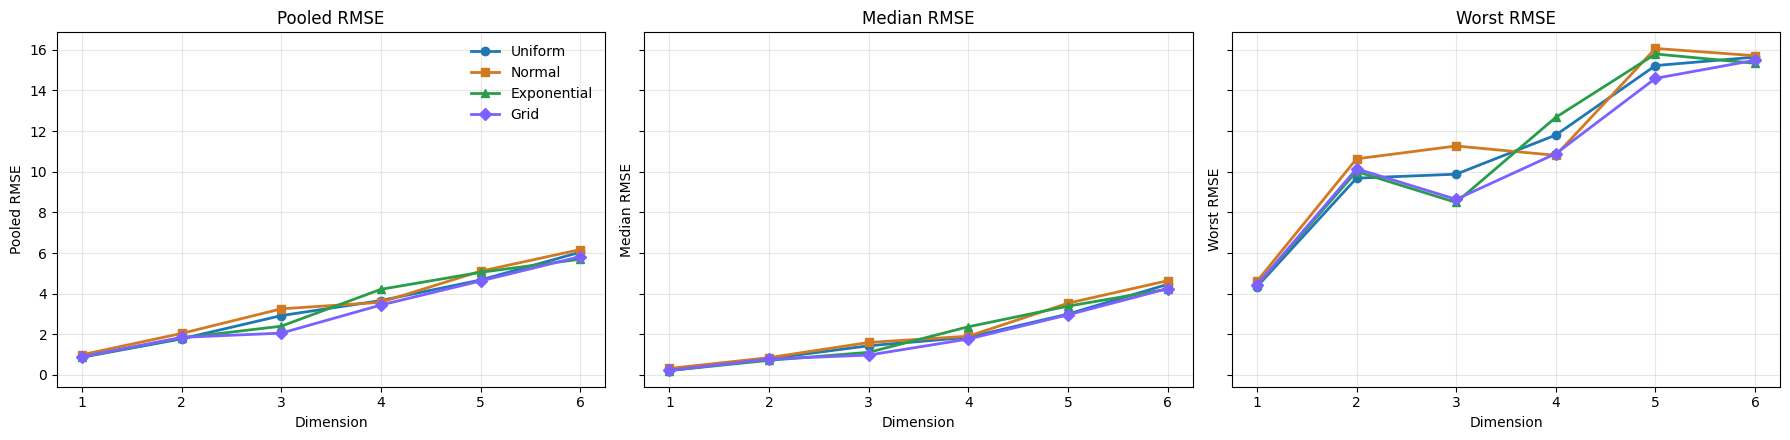

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True, sharey=True)
plot_prior_lines(axes[0], runs_df, "pooled_rmse_log_r10", "Pooled RMSE", "Pooled RMSE")
plot_prior_lines(axes[1], runs_df, "median_rmse_log_r10", "Median RMSE", "Median RMSE")
plot_prior_lines(axes[2], runs_df, "worst_rmse_log_r10", "Worst RMSE", "Worst RMSE")
axes[0].legend(frameon=False)
fig.tight_layout()
save_figure(fig, "scaling_rmse_vs_dimension")
plt.show()

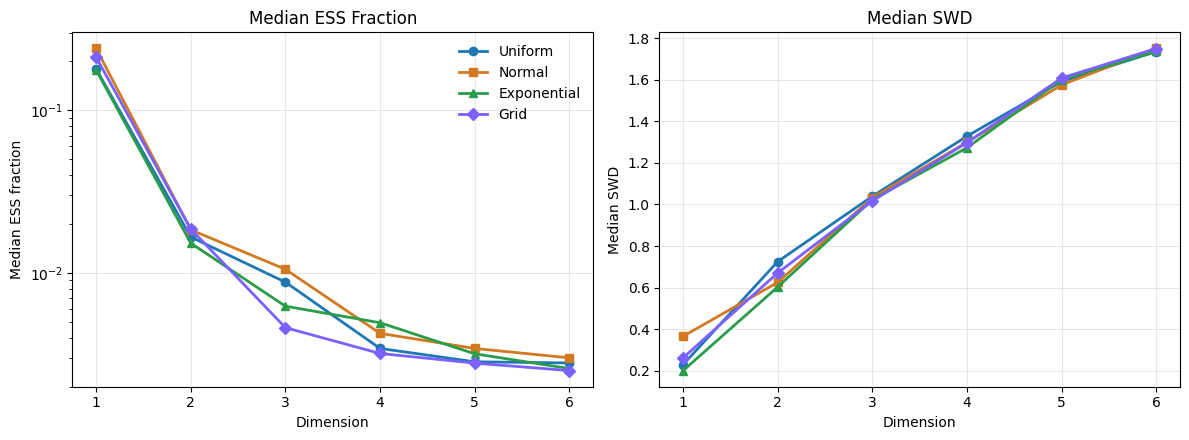

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
plot_prior_lines(axes[0], runs_df, "median_ess_fraction", "Median ESS Fraction", "Median ESS fraction", logy=True)
plot_prior_lines(axes[1], runs_df, "median_swd", "Median SWD", "Median SWD")
axes[0].legend(frameon=False)
fig.tight_layout()
save_figure(fig, "scaling_reweighting_metrics_vs_dimension")
plt.show()

In [4]:
display(build_scaling_observation_markdown(runs_df))

### Scaling interpretation
- The sharpest average pooled-RMSE jump occurs between **1D** and **2D**, where the mean pooled RMSE rises from **0.91** to **1.87**.
- Mean 68% HLD coverage drops below **0.50** at **6D**, which is a strong sign that uncertainty is becoming under-dispersed in the higher-dimensional runs.
- Median effective-sample-size fraction falls below **1%** by **3D**, which matches the worsening reweighting difficulty seen in the SWD plots.
- By **6D**, the sweep combines larger ratio error, lower ESS, and much weaker empirical coverage, so the failure mode is not just a single metric moving in isolation.

## Calibration And Uncertainty

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
plot_prior_lines(axes[0], runs_df, "coverage_68", "Empirical 68% HLD Coverage", "Coverage")
plot_prior_lines(axes[1], runs_df, "coverage_95", "Empirical 95% HLD Coverage", "Coverage")
axes[0].axhline(0.68, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
axes[1].axhline(0.95, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
axes[0].legend(frameon=False)
fig.tight_layout()
save_figure(fig, "calibration_coverage_vs_dimension")
plt.show()

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
plot_prior_lines(axes[0], runs_df, "mean_interval_width_68", "Mean 68% HLD Width", "Width")
plot_prior_lines(axes[1], runs_df, "mean_interval_width_95", "Mean 95% HLD Width", "Width")
axes[0].legend(frameon=False)
fig.tight_layout()
save_figure(fig, "calibration_interval_width_vs_dimension")
plt.show()

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=False, sharey=True)
scatter = None
for ax, level in zip(axes, [68, 95]):
    coverage_col = f"coverage_{level}"
    width_col = f"mean_interval_width_{level}"
    for prior in PRIORS:
        subset = runs_df.loc[runs_df["prior"] == prior]
        if subset.empty:
            continue
        scatter = ax.scatter(
            subset[width_col],
            subset[coverage_col],
            c=subset["dimension"],
            cmap="viridis",
            s=90,
            marker=PRIOR_MARKERS.get(prior, "o"),
            alpha=0.85,
            edgecolor="black",
            linewidth=0.5,
        )
    ax.axhline(level / 100.0, color="black", linestyle="--", linewidth=1.2, alpha=0.75)
    ax.set_title(f"Coverage vs width ({level}% HLD)")
    ax.set_xlabel("Mean interval width")
    ax.set_ylabel("Empirical coverage")
    ax.grid(alpha=0.25)
legend_handles = build_prior_legend_handles(active_priors(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Prior")
if scatter is not None:
    add_shared_colorbar(fig, axes, scatter, "Dimension", right=0.88, pad=0.03, top=0.9, bottom=0.14, left=0.08, wspace=0.28)
else:
    fig.subplots_adjust(left=0.08, right=0.98, bottom=0.14, top=0.9, wspace=0.28)
save_figure(fig, "calibration_coverage_vs_width")
plt.show()

## Distance-Driven Difficulty

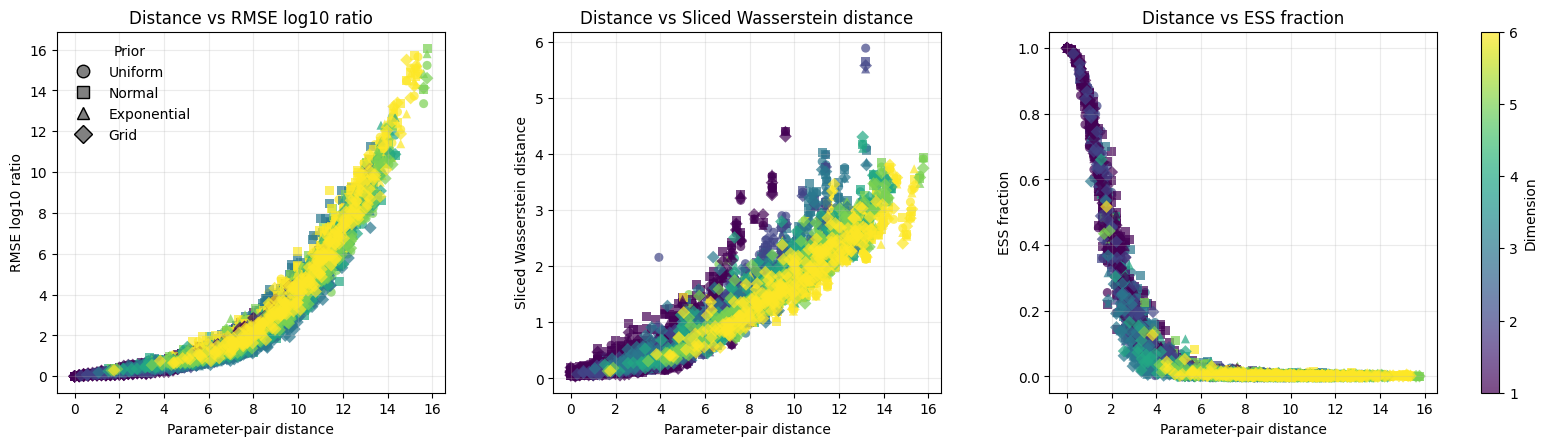

In [11]:
metrics = [
    ("rmse_log_r10", "RMSE log10 ratio"),
    ("swd", "Sliced Wasserstein distance"),
    ("ess_fraction", "ESS fraction"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.75), sharex=True)
scatter = None
for ax, (metric, ylabel) in zip(axes, metrics):
    for prior in PRIORS:
        subset = pairs_df.loc[pairs_df["prior"] == prior]
        if subset.empty:
            continue
        scatter = ax.scatter(
            subset["distance"],
            subset[metric],
            c=subset["dimension"],
            cmap="viridis",
            s=42,
            alpha=0.70,
            marker=PRIOR_MARKERS.get(prior, "o"),
            edgecolor="none",
        )
    ax.set_title(f"Distance vs {ylabel}")
    ax.set_xlabel("Parameter-pair distance")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
legend_handles = build_prior_legend_handles(active_priors(pairs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Prior")
if scatter is not None:
    add_shared_colorbar(fig, axes, scatter, "Dimension", right=0.88, pad=0.03, top=0.9, bottom=0.14, left=0.06, wspace=0.28)
else:
    fig.subplots_adjust(left=0.06, right=0.98, bottom=0.14, top=0.9, wspace=0.28)
save_figure(fig, "difficulty_distance_vs_metrics")
plt.show()

In [12]:
display(correlation_summary_df)

,config_id,dimension,prior,stored_spearman_rmse_vs_distance,empirical_spearman_rmse_vs_distance,empirical_pearson_rmse_vs_distance,stored_spearman_swd_vs_distance,empirical_spearman_swd_vs_distance,empirical_pearson_swd_vs_distance,empirical_spearman_ess_fraction_vs_distance
0,config_018,1,exponential,0.975,0.975,0.869,0.878,0.878,0.813,-0.990
1,config_018,1,grid,0.929,0.929,0.860,0.857,0.857,0.823,-0.990
2,config_018,1,normal,0.970,0.970,0.885,0.866,0.866,0.846,-0.979
3,config_018,1,uniform,0.963,0.963,0.858,0.839,0.839,0.803,-0.988
4,config_013,2,exponential,0.987,0.987,0.862,0.961,0.961,0.887,-0.936
5,config_013,2,grid,0.985,0.985,0.865,0.948,0.948,0.885,-0.928
6,config_013,2,normal,0.990,0.990,0.877,0.961,0.961,0.890,-0.936
7,config_013,2,uniform,0.970,0.970,0.863,0.922,0.922,0.862,-0.918
8,config_012,3,exponential,0.988,0.988,0.895,0.962,0.962,0.924,-0.848
9,config_012,3,grid,0.971,0.971,0.855,0.938,0.938,0.910,-0.805


## Position-Dependent Behavior

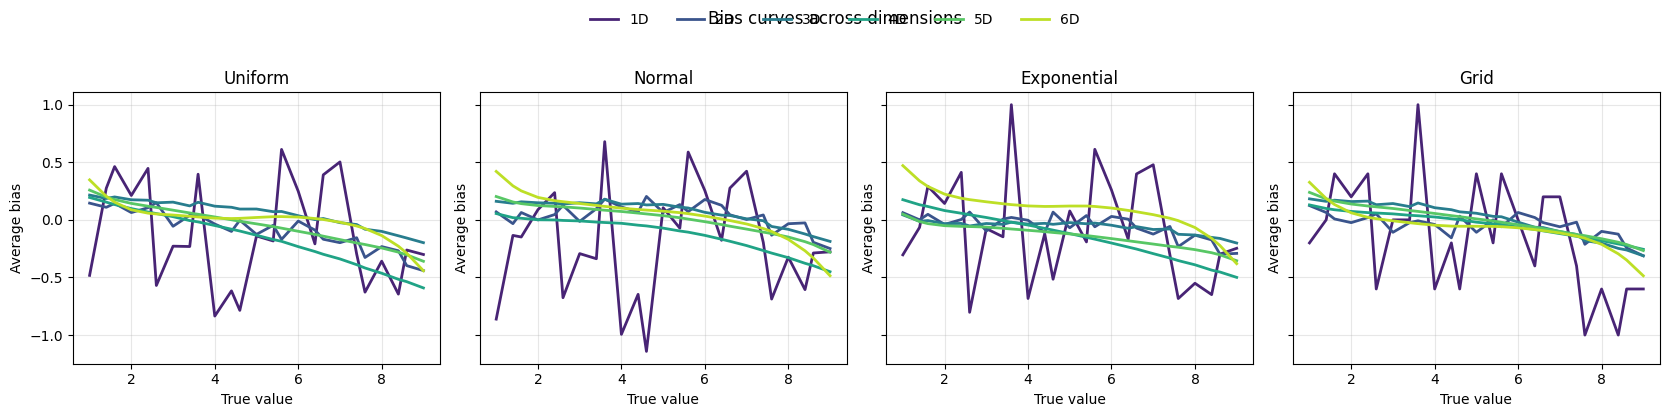

In [13]:
fig = plot_curve_family(curves_df, "avg_bias", "Average bias", "Bias curves across dimensions")
save_figure(fig, "position_avg_bias_curves")
plt.show()

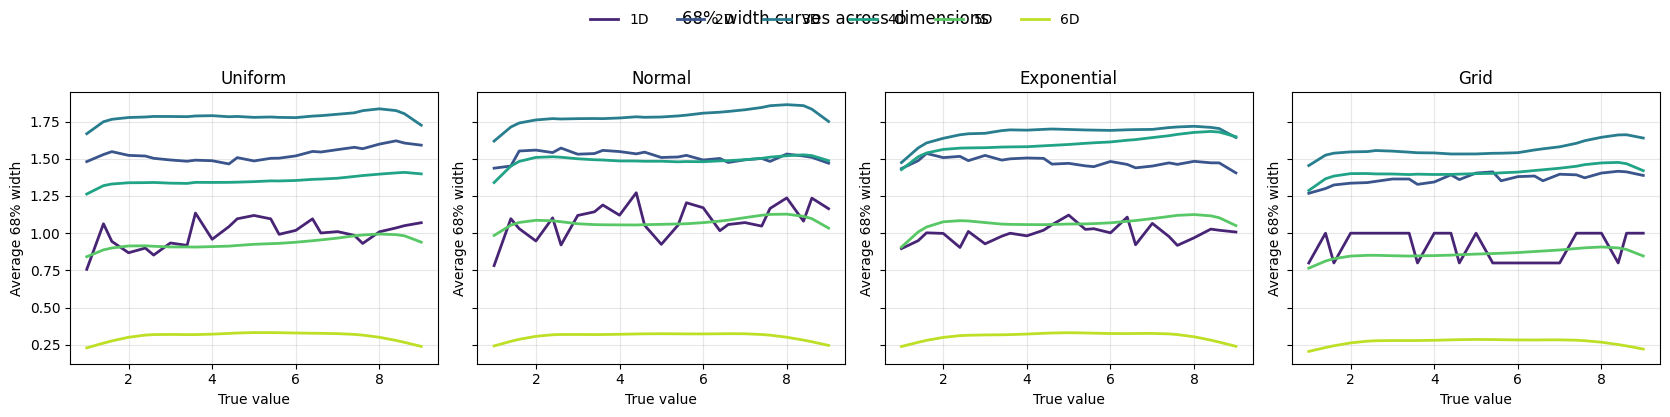

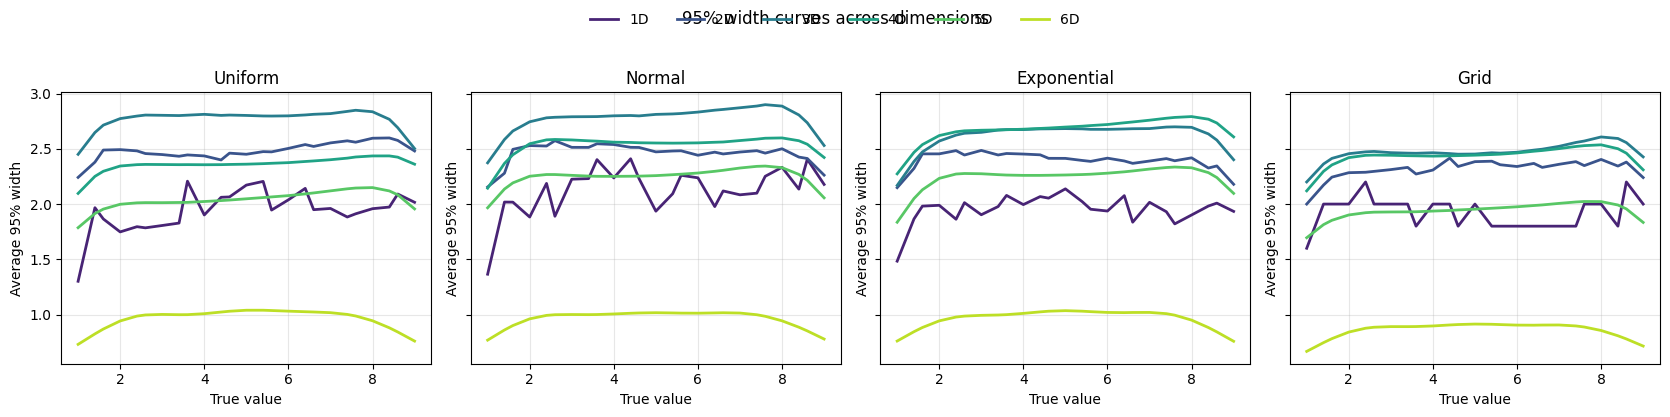

In [14]:
fig = plot_curve_family(curves_df, "avg_width_68", "Average 68% width", "68% width curves across dimensions")
save_figure(fig, "position_avg_width_68_curves")
plt.show()

fig = plot_curve_family(curves_df, "avg_width_95", "Average 95% width", "95% width curves across dimensions")
save_figure(fig, "position_avg_width_95_curves")
plt.show()

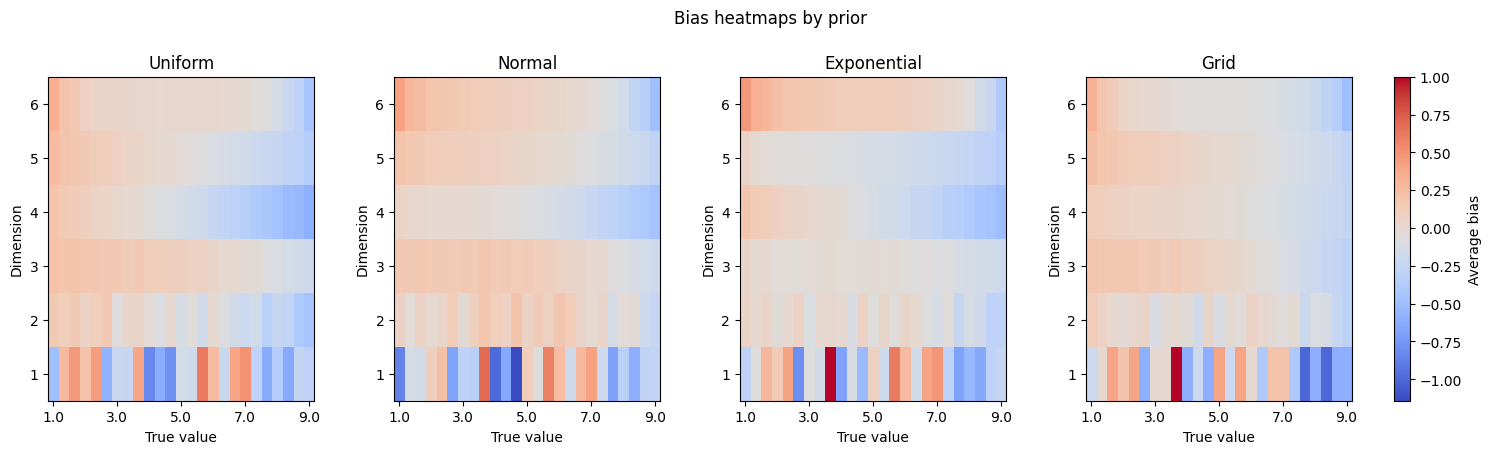

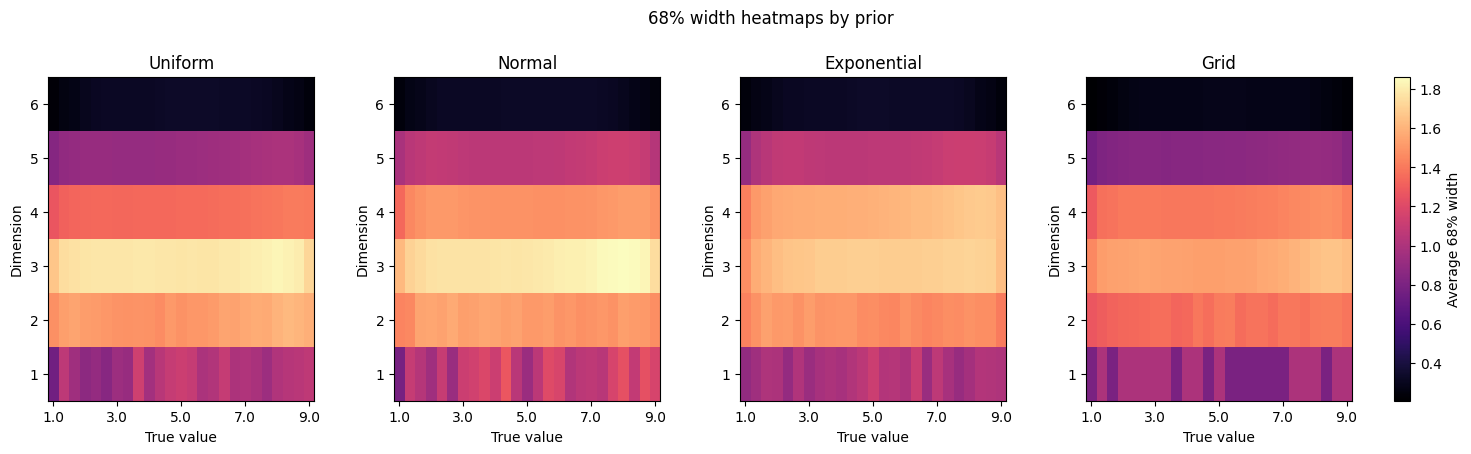

In [15]:
fig = plot_curve_heatmaps(curves_df, "avg_bias", "Average bias", cmap="coolwarm")
fig.suptitle("Bias heatmaps by prior", y=1.03)
save_figure(fig, "position_avg_bias_heatmap")
plt.show()

fig = plot_curve_heatmaps(curves_df, "avg_width_68", "Average 68% width", cmap="magma")
fig.suptitle("68% width heatmaps by prior", y=1.03)
save_figure(fig, "position_avg_width_68_heatmap")
plt.show()

## Raw Deep Dive (Optional)

In [16]:
if not LOAD_RAW:
    display(
        Markdown(
            f"Set `LOAD_RAW = True` to enable the compact-store deep dive. "
            f"The loader will automatically sample very large arrays down to at most **{RAW_MAX_POINTS_PER_CONFIG:,}** posterior settings per config/prior. For high-dimensional raw deep dives, it is usually best to narrow `PRIORS` to the specific prior you want to inspect."
        )
    )
elif raw_metadata_df.empty:
    display(Markdown("Raw loading was enabled, but no raw compact-store artifacts were available for the requested configs."))
else:
    display(raw_metadata_df)

,config_id,dimension,prior,n_total_points,n_loaded_points,sampled
0,config_018,1,exponential,25,25,False
1,config_018,1,grid,25,25,False
2,config_018,1,normal,25,25,False
3,config_018,1,uniform,25,25,False
4,config_013,2,exponential,625,625,False
5,config_013,2,grid,625,625,False
6,config_013,2,normal,625,625,False
7,config_013,2,uniform,625,625,False
8,config_012,3,exponential,15625,10000,True
9,config_012,3,grid,15625,10000,True


In [8]:

PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
requested_config_ids = normalized_config_ids(CONFIG_IDS)
summary_payload = load_dimensionality_summary(FIGS_ROOT, CONFIG_IDS, PRIORS)
config_overview_df = summary_payload["config_overview_df"]
runs_df = summary_payload["runs_df"]
pairs_df = summary_payload["pairs_df"]
curves_df = summary_payload["curves_df"]
resolved_config_ids = summary_payload["resolved_config_ids"]
skipped_config_ids = [config_id for config_id in requested_config_ids if config_id not in resolved_config_ids]
compact_metric_df = build_compact_metric_table(runs_df)
correlation_summary_df = build_correlation_summary(runs_df, pairs_df)
raw_payload = load_raw_compact_store(FIGS_ROOT, RAW_CONFIG_IDS, ["uniform"], max_points_per_config=RAW_MAX_POINTS_PER_CONFIG)
raw_map_df = raw_payload["raw_map_df"]
raw_intervals_df = raw_payload["raw_intervals_df"]
raw_metadata_df = raw_payload["raw_metadata_df"]
LOAD_RAW = True
